# Logistic Regression 이커머스 이탈 예측 모델링

1. 데이터 불러오기
2. Baseline 모델 학습
3. feature 조합 비교
4. C 값 비교
5. threshold별 Recall과 Precision 확인
6. 계수 해석
7. 최종 정리

Test 데이터는 팀의 최종 후보가 정해질 때까지 사용하지 않습니다.

## 0. 데이터 로드

팀 공통 전처리 데이터를 사용합니다. Train 데이터로 학습하고 Validation 데이터로만 모델을 비교합니다.

In [40]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    precision_score,
    fbeta_score,
    recall_score,
    roc_auc_score,
)

RANDOM_STATE = 42
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 노트북 실행 위치에 관계없이 프로젝트 루트의 data 폴더를 찾음
PROJECT_DIR = Path.cwd().resolve()
while not (PROJECT_DIR / "data" / "preprocessed").exists():
    if PROJECT_DIR.parent == PROJECT_DIR:
        raise FileNotFoundError("data/preprocessed 폴더를 찾을 수 없음")
    PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = PROJECT_DIR / "data" / "preprocessed"

# Test 데이터는 불러오지 않습니다.
X_train = pd.read_csv(DATA_DIR / "X_train.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv")["churn"]
X_val = pd.read_csv(DATA_DIR / "X_val.csv")
y_val = pd.read_csv(DATA_DIR / "y_val.csv")["churn"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("Train 이탈률:", round(y_train.mean(), 3))
print("Validation 이탈률:", round(y_val.mean(), 3))

X_train: (2592, 10)
X_val: (864, 10)
Train 이탈률: 0.494
Validation 이탈률: 0.494


In [41]:
display(X_train.head())
print(X_train.columns.tolist())

,net_revenue,recency_days,frequency,distinct_products,tenure_days,avg_days_between_orders,is_low_value,is_uk,has_return,recent_activity_ratio
0,-0.671757,1.614952,-0.407252,-0.671793,-0.406069,0.616805,0.0,1.0,1.0,0.0
1,-0.965400,-0.314654,-0.475206,-0.745705,-1.605762,-0.078723,0.0,1.0,0.0,0.0
2,-1.073778,0.274474,-0.475206,-0.736466,-1.245854,0.695333,0.0,1.0,0.0,0.0
3,-0.542093,-1.091619,-0.475206,-0.440820,-2.080423,-1.099580,0.0,1.0,0.0,1.0
4,-0.942516,0.641611,-0.407252,-0.487015,-0.473878,0.543887,1.0,1.0,0.0,0.0


['net_revenue', 'recency_days', 'frequency', 'distinct_products', 'tenure_days', 'avg_days_between_orders', 'is_low_value', 'is_uk', 'has_return', 'recent_activity_ratio']


## 1단계: Baseline 모델

가장 먼저 모든 feature를 사용한 기본 Logistic Regression을 만듭니다.


In [42]:
# 1. 모델 만들기
baseline_model = LogisticRegression(random_state=RANDOM_STATE)

# 2. Train 데이터로 학습하기
baseline_model.fit(X_train, y_train)

# 3. Validation 데이터의 이탈 확률과 예측값 만들기
baseline_probability = baseline_model.predict_proba(X_val)[:, 1]
baseline_pred = baseline_model.predict(X_val)

# 4. 성능 확인하기
baseline_recall = recall_score(y_val, baseline_pred)
baseline_precision = precision_score(y_val, baseline_pred)
baseline_auc = roc_auc_score(y_val, baseline_probability)
baseline_pr_auc = average_precision_score(y_val, baseline_probability)

print("Recall:", round(baseline_recall, 3))
print("Precision:", round(baseline_precision, 3))
print("ROC-AUC:", round(baseline_auc, 3))
print("PR-AUC:", round(baseline_pr_auc, 3))

Recall: 0.667
Precision: 0.707
ROC-AUC: 0.759
PR-AUC: 0.731


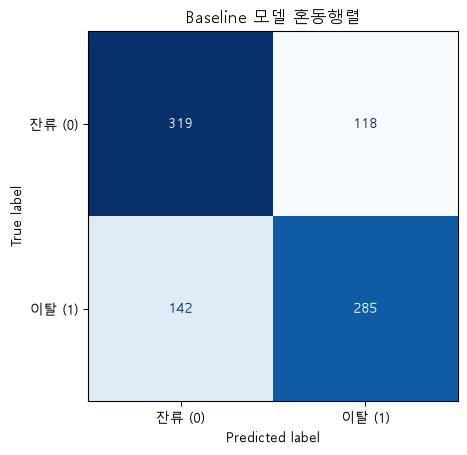

In [43]:
# Baseline 모델이 맞힌 고객과 틀린 고객 수를 확인합니다.
ConfusionMatrixDisplay.from_predictions(
    y_val,
    baseline_pred,
    display_labels=["잔류 (0)", "이탈 (1)"],
    cmap="Blues",
    colorbar=False,
)
plt.title("Baseline 모델 혼동행렬")
plt.show()

### 해석

- Recall은 실제 이탈 고객 중 모델이 이탈이라고 맞힌 비율입니다.
- Precision은 모델이 이탈이라고 예측한 고객 중 실제 이탈 고객의 비율입니다.
- ROC-AUC와 PR-AUC는 threshold를 바꾸기 전, 모델이 이탈 고객과 잔류 고객을 얼마나 잘 구분하는지 보여줍니다.

다음 단계에서는 상관관계가 높은 feature를 일부 제거해도 성능이 유지되는지 확인합니다.

## 2단계: README 규칙을 반영한 feature 선택

README를 참고하여 recency_days와 avg_days_between_orders 중 하나만 씁니다.

all_10은 기준선으로만 확인하고, 이후 모델 비교와 최종 후보 선정은 9개 feature를 사용하는 recency_feature_set으로 진행합니다.

In [44]:
# all_10 조합은 기준선 비교용입니다.
all_10_features = X_train.columns.tolist()

all_10_model = LogisticRegression(random_state=RANDOM_STATE)
all_10_model.fit(X_train[all_10_features], y_train)

all_10_probability = all_10_model.predict_proba(X_val[all_10_features])[:, 1]
all_10_pred = all_10_model.predict(X_val[all_10_features])

In [45]:
recency_features = [
    feature
    for feature in X_train.columns
    if feature != "avg_days_between_orders"
]

recency_model = LogisticRegression(random_state=RANDOM_STATE)
recency_model.fit(X_train[recency_features], y_train)

recency_probability = recency_model.predict_proba(X_val[recency_features])[:, 1]
recency_pred = recency_model.predict(X_val[recency_features])

In [46]:
# 기준선(all_10)과 README 권장 조합(recency_feature_set)을 비교합니다.
feature_comparison = pd.DataFrame(
    [
        {
            "feature_set": "all_10 (baseline only)",
            "feature_count": len(all_10_features),
            "recall": recall_score(y_val, all_10_pred),
            "precision": precision_score(y_val, all_10_pred),
            "roc_auc": roc_auc_score(y_val, all_10_probability),
            "pr_auc": average_precision_score(y_val, all_10_probability),
        },
        {
            "feature_set": "recency_feature_set",
            "feature_count": len(recency_features),
            "recall": recall_score(y_val, recency_pred),
            "precision": precision_score(y_val, recency_pred),
            "roc_auc": roc_auc_score(y_val, recency_probability),
            "pr_auc": average_precision_score(y_val, recency_probability),
        },
    ]
).sort_values("pr_auc", ascending=False)

display(feature_comparison.style.format({
    "recall": "{:.3f}",
    "precision": "{:.3f}",
    "roc_auc": "{:.3f}",
    "pr_auc": "{:.3f}",
}))

,feature_set,feature_count,recall,precision,roc_auc,pr_auc
0,all_10 (baseline only),10,0.667,0.707,0.759,0.731
1,recency_feature_set,9,0.677,0.690,0.757,0.730


### 해석

avg_days_between_orders를 제거한 9개 feature 조합을 이후 하이퍼파라미터 비교의 공통 입력으로 사용합니다.

이렇게 하면 다중공선성 우려를 줄이고, 마지막 구매 이후 경과일이라는 직관적인 기준으로 모델을 설명할 수 있습니다.

## 3단계: C 값 비교

C는 Logistic Regression의 규제 강도를 정하는 값입니다.

- C가 작으면 규제가 강해져 계수가 너무 커지는 것을 막습니다.
- C가 크면 규제가 약해져 데이터에 더 맞추려고 합니다.

avg_days_between_orders를 제외한 recency_feature_set을 고정하고 C 값만 0.1, 1, 10으로 바꿔 비교합니다. L2 규제를 기본값으로 사용합니다.

In [47]:
# C 값만 바꿔서 모델을 세 번 학습합니다.
c_values = [0.1, 1, 10]
hyperparameter_results = []

for c_value in c_values:
    model = LogisticRegression(
        C=c_value,
        solver="liblinear",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )

    # 학습
    model.fit(X_train[recency_features], y_train)

    probability = model.predict_proba(X_val[recency_features])[:, 1]
    pred = model.predict(X_val[recency_features])

    hyperparameter_results.append(
        {
            "C": c_value,
            "recall": recall_score(y_val, pred),
            "precision": precision_score(y_val, pred),
            "roc_auc": roc_auc_score(y_val, probability),
            "pr_auc": average_precision_score(y_val, probability),
        }
    )

hyperparameter_comparison = pd.DataFrame(hyperparameter_results).sort_values(
    "pr_auc", ascending=False
).reset_index(drop=True)

display(hyperparameter_comparison.style.format({
    "recall": "{:.3f}",
    "precision": "{:.3f}",
    "roc_auc": "{:.3f}",
    "pr_auc": "{:.3f}",
}))

,C,recall,precision,roc_auc,pr_auc
0,10.000000,0.679,0.687,0.757,0.730
1,1.000000,0.677,0.690,0.757,0.730
2,0.100000,0.672,0.688,0.757,0.730


## 4단계: 후보 1 - 기본 운영 기준

앞 단계에서 C 값을 비교해 Logistic Regression 모델 설정을 확정했습니다.

후보 1은 기본 threshold 0.50을 적용한 기준 모델입니다. 이후 후보 2에서는 같은 모델에 threshold를 낮춰 Recall을 높입니다.

In [48]:
# 팀에 공유할 최종 Logistic Regression 후보입니다.
# README 규칙: avg_days_between_orders를 제외하고 recency_days를 사용합니다.
FINAL_FEATURES = recency_features
FINAL_C = 10

final_model = LogisticRegression(
    C=FINAL_C,
    solver="liblinear",
    max_iter=2000,
    random_state=RANDOM_STATE,
)

# 최종 후보 모델을 Train 데이터로 학습합니다.
final_model.fit(X_train[FINAL_FEATURES], y_train)

# Validation 데이터에서 최종 후보의 성능을 확인합니다.
final_probability = final_model.predict_proba(X_val[FINAL_FEATURES])[:, 1]
final_pred = final_model.predict(X_val[FINAL_FEATURES])

final_model_metrics = pd.DataFrame(
    [
        {
            "model": "후보 1: 기본 threshold 0.50",
            "feature_count": len(FINAL_FEATURES),
            "excluded_feature": "avg_days_between_orders",
            "C": FINAL_C,
            "solver": "liblinear",
            "recall": recall_score(y_val, final_pred),
            "precision": precision_score(y_val, final_pred),
            "roc_auc": roc_auc_score(y_val, final_probability),
            "pr_auc": average_precision_score(y_val, final_probability),
        }
    ]
)

display(final_model_metrics.style.format({
    "recall": "{:.3f}",
    "precision": "{:.3f}",
    "roc_auc": "{:.3f}",
    "pr_auc": "{:.3f}",
}))

,model,feature_count,excluded_feature,C,solver,recall,precision,roc_auc,pr_auc
0,후보 1: 기본 threshold 0.50,9,avg_days_between_orders,10,liblinear,0.679,0.687,0.757,0.730


### 후보 1 혼동행렬: 기본 threshold 0.50

기본 threshold 0.50에서 최종 후보가 실제 이탈 고객과 잔류 고객을 어떻게 분류했는지 확인합니다.

- 오른쪽 아래: 실제 이탈을 이탈로 맞힌 고객
- 왼쪽 아래: 실제 이탈을 잔류로 예측해 놓친 고객
- 오른쪽 위: 실제 잔류를 이탈로 잘못 예측한 고객

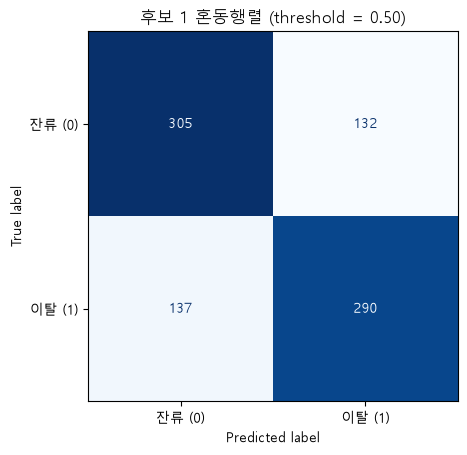

In [49]:
final_confusion_matrix = confusion_matrix(y_val, final_pred)

ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix,
    display_labels=["잔류 (0)", "이탈 (1)"],
).plot(cmap="Blues", colorbar=False)

plt.title("후보 1 혼동행렬 (threshold = 0.50)")
plt.show()

### 해석

이 단계에서는 Recall만 보고 모델을 고르지 않습니다. threshold를 낮추면 Recall은 쉽게 커질 수 있기 때문입니다.

PR-AUC와 ROC-AUC가 가장 높은 C 값을 먼저 고른 뒤, 마지막에 threshold를 바꿔 운영 상황에 맞는 Recall과 Precision을 정합니다.

## 5단계: 후보 2 - Recall 우선 운영 기준

후보 2는 후보 1과 같은 Logistic Regression 모델을 사용하지만, threshold를 낮춰 실제 이탈 고객을 더 많이 탐지하는 운영안입니다.

threshold를 낮추면 이탈로 예측하는 고객이 늘어나 Recall은 높아집니다. 하지만 threshold를 너무 낮추면 거의 모든 고객을 이탈로 예측하게 되어 Precision과 캠페인 효율이 크게 떨어집니다.

따라서 아래 기준을 함께 확인합니다.

- F2-score: Recall에 Precision보다 2배 큰 가중치를 주는 지표
- Precision 최소 기준: 이탈이라고 예측한 고객의 최소 60%는 실제 이탈 고객으로 유지

후보 2는 Precision 0.60 이상을 만족하는 값 중 Recall이 가장 높은 threshold를 사용합니다.

In [50]:
# threshold를 0.05부터 0.95까지 0.01 간격으로 비교합니다.
# 이탈을 놓치지 않는 것이 중요하지만, 오탐이 과도해지는 것은 막기 위해
# Precision 최소 기준을 0.60으로 둡니다.
MIN_PRECISION = 0.60
threshold_results = []

for threshold in np.arange(0.05, 0.96, 0.01):
    threshold = round(float(threshold), 2)
    threshold_pred = (final_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, threshold_pred).ravel()

    threshold_results.append(
        {
            "threshold": threshold,
            "recall": recall_score(y_val, threshold_pred),
            "precision": precision_score(y_val, threshold_pred, zero_division=0),
            "f2": fbeta_score(y_val, threshold_pred, beta=2, zero_division=0),
            "false_negative": fn,
            "false_positive": fp,
        }
    )

threshold_comparison = pd.DataFrame(threshold_results)

# Recall만 강하게 반영한 F2-score의 최댓값도 참고용으로 확인합니다.
best_f2_row = threshold_comparison.loc[
    threshold_comparison["f2"].idxmax()
]

# 운영 추천값: Precision 0.60 이상을 유지하면서 Recall이 가장 높은 threshold
recall_priority_candidates = threshold_comparison[
    threshold_comparison["precision"] >= MIN_PRECISION
]
recommended_threshold_row = recall_priority_candidates.sort_values(
    ["recall", "precision"], ascending=False
).iloc[0]

RECOMMENDED_THRESHOLD = float(recommended_threshold_row["threshold"])
recommended_pred = (final_probability >= RECOMMENDED_THRESHOLD).astype(int)

print("F2-score 최대 threshold")
display(best_f2_row.to_frame("value"))

print(f"추천 기준: Precision >= {MIN_PRECISION:.2f} 중 Recall 최대")
display(recommended_threshold_row.to_frame("value"))

print("추천값과 기본값(0.50) 비교")
display(
    threshold_comparison[
        threshold_comparison["threshold"].isin([RECOMMENDED_THRESHOLD, 0.50])
    ].style.format({
        "threshold": "{:.2f}",
        "recall": "{:.3f}",
        "precision": "{:.3f}",
        "f2": "{:.3f}",
    })
)

F2-score 최대 threshold


,value
threshold,0.220000
recall,0.967213
precision,0.553619
f2,0.841483
false_negative,14.000000
false_positive,333.000000


추천 기준: Precision >= 0.60 중 Recall 최대


,value
threshold,0.340000
recall,0.882904
precision,0.610032
f2,0.810404
false_negative,50.000000
false_positive,241.000000


추천값과 기본값(0.50) 비교


,threshold,recall,precision,f2,false_negative,false_positive
29,0.34,0.883,0.610,0.810,50,241
45,0.50,0.679,0.687,0.681,137,132


In [51]:
# 후보 2의 성능을 후보 1과 같은 형식으로 정리합니다.
candidate_2_metrics = pd.DataFrame(
    [
        {
            "model": f"후보 2: Recall 우선 threshold {RECOMMENDED_THRESHOLD:.2f}",
            "feature_count": len(FINAL_FEATURES),
            "C": FINAL_C,
            "threshold": RECOMMENDED_THRESHOLD,
            "recall": recall_score(y_val, recommended_pred),
            "precision": precision_score(y_val, recommended_pred),
            "false_negative": int((y_val.values == 1).sum() - recommended_pred[y_val.values == 1].sum()),
            "false_positive": int(((y_val.values == 0) & (recommended_pred == 1)).sum()),
        }
    ]
)

display(candidate_2_metrics.style.format({
    "threshold": "{:.2f}",
    "recall": "{:.3f}",
    "precision": "{:.3f}",
}))

,model,feature_count,C,threshold,recall,precision,false_negative,false_positive
0,후보 2: Recall 우선 threshold 0.34,9,10,0.34,0.883,0.610,50,241


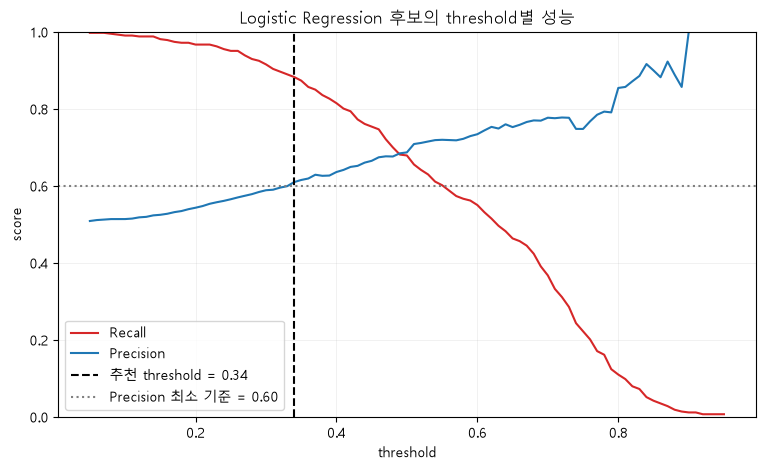

In [52]:
# threshold에 따라 Recall과 Precision이 어떻게 달라지는지 그래프로 확인합니다.
plt.figure(figsize=(9, 5))
plt.plot(
    threshold_comparison["threshold"],
    threshold_comparison["recall"],
    label="Recall",
    color="tab:red",
)
plt.plot(
    threshold_comparison["threshold"],
    threshold_comparison["precision"],
    label="Precision",
    color="tab:blue",
)
plt.axvline(
    RECOMMENDED_THRESHOLD,
    color="black",
    linestyle="--",
    label=f"추천 threshold = {RECOMMENDED_THRESHOLD:.2f}",
)
plt.axhline(
    MIN_PRECISION,
    color="gray",
    linestyle=":",
    label=f"Precision 최소 기준 = {MIN_PRECISION:.2f}",
)
plt.xlabel("threshold")
plt.ylabel("score")
plt.ylim(0, 1)
plt.title("Logistic Regression 후보의 threshold별 성능")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### 후보 2 혼동행렬: Recall 우선 threshold 적용

아래 혼동행렬은 후보 1의 기본 threshold 0.50이 아니라, Recall 우선 기준으로 선택된 threshold 0.34를 적용한 후보 2의 결과입니다.

후보 1과 후보 2는 학습된 Logistic Regression 모델 자체는 같고, 고객을 이탈로 판단하는 threshold만 다릅니다.

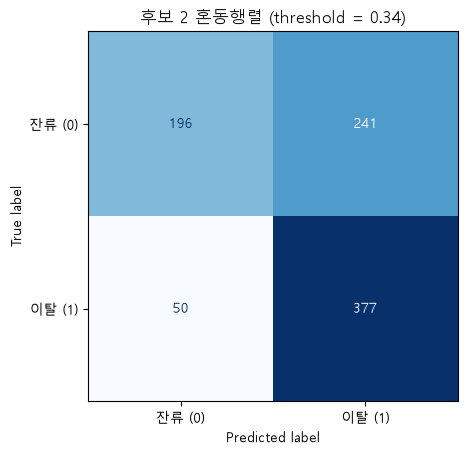

In [53]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    recommended_pred,
    display_labels=["잔류 (0)", "이탈 (1)"],
    cmap="Blues",
    colorbar=False,
)
plt.title(
    f"후보 2 혼동행렬 (threshold = {RECOMMENDED_THRESHOLD:.2f})"
)
plt.show()

### 해석

- false_negative는 실제 이탈 고객을 놓친 수입니다.
- false_positive는 실제 잔류 고객을 이탈로 잘못 예측한 수입니다.

쿠폰이나 이메일 발송 비용이 낮다면 threshold를 낮춰 Recall을 높일 수 있습니다. 반대로 상담이나 큰 할인처럼 비용이 크다면 threshold를 높여 false_positive를 줄이는 편이 좋습니다.

### 후보 3: Recall 0.85 이상 · F1-score 최대 threshold

Recall을 0.85 이상으로 유지하면서 Precision과 Recall의 균형(F1-score)이 가장 좋은 threshold를 선택합니다.


In [54]:
# Recall 0.85 이상을 만족하는 threshold 중 F1-score가 최대인 지점을 찾습니다.
# F1은 Precision과 Recall의 균형을 보는 지표입니다.
MIN_RECALL = 0.85

f1_threshold_comparison = threshold_comparison.copy()
f1_threshold_comparison["f1"] = (
    2
    * f1_threshold_comparison["precision"]
    * f1_threshold_comparison["recall"]
    / (
        f1_threshold_comparison["precision"]
        + f1_threshold_comparison["recall"]
    )
).fillna(0)

recall_85_candidates = f1_threshold_comparison[
    f1_threshold_comparison["recall"] >= MIN_RECALL
]

if recall_85_candidates.empty:
    raise ValueError(f"Recall >= {MIN_RECALL:.2f}를 만족하는 threshold가 없습니다.")

# F1이 가장 큰 값을 선택하고, F1이 같다면 Precision이 높은 값을 우선합니다.
best_f1_recall85_row = recall_85_candidates.sort_values(
    ["f1", "precision", "recall"], ascending=False
).iloc[0]

BEST_THRESHOLD_RECALL_85_F1 = float(best_f1_recall85_row["threshold"])

print(f"추천 기준: Recall >= {MIN_RECALL:.2f} 중 F1-score 최대")
display(best_f1_recall85_row.to_frame("value"))

print("Recall 조건을 만족하는 상위 5개 threshold")
display(
    recall_85_candidates.sort_values(["f1", "precision"], ascending=False)
    .head(5)
    .style.format({
        "threshold": "{:.2f}",
        "recall": "{:.3f}",
        "precision": "{:.3f}",
        "f1": "{:.3f}",
        "f2": "{:.3f}",
    })
)


추천 기준: Recall >= 0.85 중 F1-score 최대


,value
threshold,0.370000
recall,0.850117
precision,0.629116
f2,0.794311
false_negative,64.000000
false_positive,214.000000
f1,0.723108


Recall 조건을 만족하는 상위 5개 threshold


,threshold,recall,precision,f2,false_negative,false_positive,f1
32,0.37,0.850,0.629,0.794,64,214,0.723
30,0.35,0.874,0.616,0.806,54,233,0.722
29,0.34,0.883,0.610,0.810,50,241,0.722
31,0.36,0.857,0.619,0.796,61,225,0.719
25,0.30,0.916,0.589,0.824,36,273,0.717


In [55]:
# 후보 3의 성능을 후보 1·2와 같은 형식으로 정리합니다.
candidate_3_pred = (
    final_probability >= BEST_THRESHOLD_RECALL_85_F1
).astype(int)

candidate_3_metrics = pd.DataFrame(
    [
        {
            "model": (
                f"후보 3: Recall >= {MIN_RECALL:.2f} 중 F1 최대 "
                f"threshold {BEST_THRESHOLD_RECALL_85_F1:.2f}"
            ),
            "feature_count": len(FINAL_FEATURES),
            "C": FINAL_C,
            "threshold": BEST_THRESHOLD_RECALL_85_F1,
            "recall": recall_score(y_val, candidate_3_pred),
            "precision": precision_score(y_val, candidate_3_pred),
            "f1": best_f1_recall85_row["f1"],
            "false_negative": best_f1_recall85_row["false_negative"],
            "false_positive": best_f1_recall85_row["false_positive"],
        }
    ]
)

display(candidate_3_metrics.style.format({
    "threshold": "{:.2f}",
    "recall": "{:.3f}",
    "precision": "{:.3f}",
    "f1": "{:.3f}",
    "false_negative": "{:.0f}",
    "false_positive": "{:.0f}",
}))



,model,feature_count,C,threshold,recall,precision,f1,false_negative,false_positive
0,후보 3: Recall >= 0.85 중 F1 최대 threshold 0.37,9,10,0.37,0.850,0.629,0.723,64,214


### 후보 3 혼동행렬: Recall 0.85 이상 · F1-score 최대 threshold 적용

아래 혼동행렬은 Recall 0.85 이상이라는 조건을 만족하면서 F1-score가 가장 큰 threshold를 적용한 결과입니다. 후보 1·2·3은 모두 같은 Logistic Regression 모델이며, 고객을 이탈로 판단하는 threshold만 다릅니다.


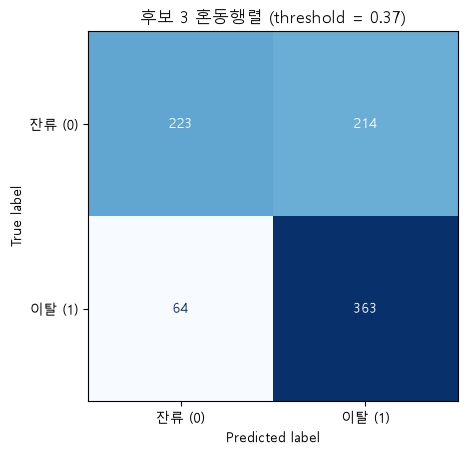

In [56]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    candidate_3_pred,
    display_labels=["잔류 (0)", "이탈 (1)"],
    cmap="Blues",
    colorbar=False,
)
plt.title(
    f"후보 3 혼동행렬 (threshold = {BEST_THRESHOLD_RECALL_85_F1:.2f})"
)
plt.show()


## 6단계: 계수 해석

Logistic Regression은 feature마다 계수를 갖습니다.

- 계수가 양수이면 이탈 쪽으로 예측하는 방향입니다.
- 계수가 음수이면 잔류 쪽으로 예측하는 방향입니다.
- 절댓값이 클수록 모델의 판단에 상대적으로 더 큰 영향을 줍니다.

계수는 예측에 사용된 신호이지, 이탈의 원인이라고 단정할 수는 없습니다.

,feature,coefficient,abs_coefficient,odds_ratio
0,net_revenue,-0.565,0.565,0.569
1,recent_activity_ratio,-0.497,0.497,0.608
2,frequency,-0.457,0.457,0.633
3,recency_days,0.358,0.358,1.430
4,distinct_products,-0.315,0.315,0.730
5,is_uk,-0.164,0.164,0.849
6,tenure_days,0.148,0.148,1.159
7,has_return,-0.076,0.076,0.927
8,is_low_value,-0.046,0.046,0.955


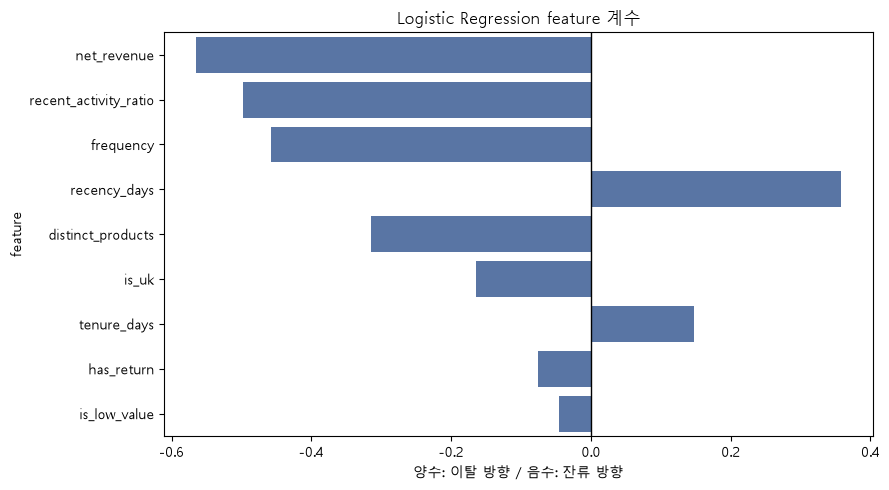

In [57]:
coefficient_table = pd.DataFrame(
    {
        "feature": recency_features,
        "coefficient": final_model.coef_[0],
    }
)
coefficient_table["abs_coefficient"] = coefficient_table["coefficient"].abs()
coefficient_table["odds_ratio"] = np.exp(coefficient_table["coefficient"])
coefficient_table = coefficient_table.sort_values(
    "abs_coefficient", ascending=False
).reset_index(drop=True)

display(coefficient_table.style.format({
    "coefficient": "{:.3f}",
    "abs_coefficient": "{:.3f}",
    "odds_ratio": "{:.3f}",
}))

plt.figure(figsize=(9, 5))
sns.barplot(data=coefficient_table, y="feature", x="coefficient", color="#4c72b0")
plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression feature 계수")
plt.xlabel("양수: 이탈 방향 / 음수: 잔류 방향")
plt.ylabel("feature")
plt.tight_layout()
plt.show()

## 최종 정리와 결론

**평가 기준**: 이커머스 리텐션 캠페인에서 실제 이탈 고객을 놓치는 비용이 크다고 판단하여 Recall을 중요 지표로 설정한다. 다만 불필요한 캠페인 대상이 과도하게 늘어나는 것을 막기 위해 Precision과 F1-score도 함께 확인한다.

### 후보 1: 기본 운영 기준

- 모델: Logistic Regression
- feature: recency_feature_set 9개
- 제외 feature: avg_days_between_orders
- C: 10
- threshold: 0.50
- Recall: 0.679
- Precision: 0.687
- 놓친 이탈 고객: 137명
- 오탐 잔류 고객: 132명

후보 1은 기본 threshold 0.50을 적용한 기준안이다. Precision은 비교적 높지만 실제 이탈 고객 137명을 놓친다.

### 후보 2: Recall 우선 운영 기준

- 학습 모델: 후보 1과 동일
- threshold: 0.34
- Recall: 0.883
- Precision: 0.610
- 놓친 이탈 고객: 50명
- 오탐 잔류 고객: 241명

후보 2는 threshold를 0.34로 낮춰 후보 1보다 실제 이탈 고객 87명을 더 탐지한다. 대신 잔류 고객 109명을 추가로 이탈로 예측한다.

### 후보 3: Recall 0.85 이상 · F1-score 최대 기준

- 학습 모델: 후보 1·2와 동일
- threshold: 0.37
- Recall: 0.850
- Precision: 0.629
- F1-score: 0.723
- 놓친 이탈 고객: 64명
- 오탐 잔류 고객: 214명

후보 3은 Recall 0.85 이상을 유지하면서 F1-score가 가장 높은 운영안이다. 후보 2보다 실제 이탈 고객을 14명 더 놓치지만, 오탐은 27명 줄어 캠페인 대상 수를 줄일 수 있다.

### 최종 결론

세 후보는 **동일한 Logistic Regression 모델에 서로 다른 threshold를 적용한 운영안**이다.

- 이탈 고객을 최대한 놓치지 않는 것이 최우선이라면 **후보 2**를 선택한다.
- Recall을 0.85 이상으로 유지하면서 오탐과 캠페인 대상을 줄이고 싶다면 **후보 3**을 선택한다.

따라서 실제 운영에서는 캠페인 예산·상담 가능 인원·할인 비용을 기준으로 후보 2와 후보 3 중 하나를 선택할 수 있다.
